In [ ]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.7 MB/s eta 0:00:00


In [ ]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.7/285.7 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.3/372.3 kB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 50.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.4/90.4 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 6.0 MB/s eta 0:0

## **Data Acquisition**

In [ ]:
import numpy as np
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.shape

(341880, 20)

In [ ]:
test.shape

(49368, 19)

In [ ]:
train.isnull().sum()

datetime             0
datetime_iso         0
time-zone            0
temp                 0
visibility      290768
d_point              0
feels                0
min_temp             0
max_temp             0
prssr                0
sea_level       148916
grnd_level      148961
hum                  0
wind_spd             0
wind_deg             0
rain_1h              0
rain_3h         149551
snow_1h         149184
snow_3h         149181
clouds               0
dtype: int64

In [ ]:
test.isnull().sum()

datetime            0
datetime_iso        0
time-zone           0
temp                0
visibility      41835
d_point             1
feels               0
min_temp            0
max_temp            0
prssr               0
sea_level       21674
grnd_level      21502
hum                 0
wind_spd            0
wind_deg            0
rain_3h         21527
snow_1h         21702
snow_3h         21565
clouds              0
dtype: int64

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341880 entries, 0 to 341879
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   datetime      341880 non-null  int64 
 1   datetime_iso  341880 non-null  object
 2   time-zone     341880 non-null  int64 
 3   temp          341880 non-null  object
 4   visibility    51112 non-null   object
 5   d_point       341880 non-null  object
 6   feels         341880 non-null  object
 7   min_temp      341880 non-null  object
 8   max_temp      341880 non-null  object
 9   prssr         341880 non-null  object
 10  sea_level     192964 non-null  object
 11  grnd_level    192919 non-null  object
 12  hum           341880 non-null  object
 13  wind_spd      341880 non-null  object
 14  wind_deg      341880 non-null  object
 15  rain_1h       341880 non-null  object
 16  rain_3h       192329 non-null  object
 17  snow_1h       192696 non-null  object
 18  snow_3h       192699 non

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49368 entries, 0 to 49367
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datetime      49368 non-null  int64 
 1   datetime_iso  49368 non-null  object
 2   time-zone     49368 non-null  int64 
 3   temp          49368 non-null  object
 4   visibility    7533 non-null   object
 5   d_point       49367 non-null  object
 6   feels         49368 non-null  object
 7   min_temp      49368 non-null  object
 8   max_temp      49368 non-null  object
 9   prssr         49368 non-null  object
 10  sea_level     27694 non-null  object
 11  grnd_level    27866 non-null  object
 12  hum           49368 non-null  object
 13  wind_spd      49368 non-null  object
 14  wind_deg      49368 non-null  object
 15  rain_3h       27841 non-null  object
 16  snow_1h       27666 non-null  object
 17  snow_3h       27803 non-null  object
 18  clouds        49368 non-null  object
dtypes: i

In [ ]:
train.head(5)

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
0,283996800,1979-01-01 00:00:00+00:00,28800,24.75 Celcius,NaN,23.89 C,25.76 C,24.28,25.22°C,1012,undetermined,NaN,95,0.82,320.0 °,zero,0,NaN,NaN,100
1,284000400,1979-01-01 01:00:00+00:00,28800,24.58 C,NaN,23.73 C,25.57 C,23.99 C,25.26 C,1012,NaN,NaN,95,0.96 m/s,338.0°,0,0,0,0,100
2,284004000,1979-01-01 02:00:00+00:00,28800,26.6 Celcius,unidentified,24.06 C,26.6 C,26.1 C,27.39,1012,NaN,undetermined,86,1.22 m/s,339.0°,0,volume:zero,NaN,NaN,99
3,284007600,1979-01-01 03:00:00+00:00,28800,27.31 Celcius,NaN,24.37 C,30.9 C,26.59,28.36 C,1012,NaN,undetermined,84,1.08 m/s,342,0.13,nol,0,NaN,94
4,284011200,1979-01-01 04:00:00+00:00,28800,27.41,NaN,25.05 C,31.54 C,26.58 C,28.31 °C,1011,NaN,undetermined,87,0.86,336.0°,0.34,nol,NaN,0,100


In [ ]:
test.head(5)

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_3h,snow_1h,snow_3h,clouds
0,1514764800,2018-01-01 00:00:00+00:00,28800,26.59 °C,NaN,23.66,26.59,26.02,27.16,1009,NaN,undetermined,84,1.45 m/s,355,0,NaN,no_snow,97
1,1514768400,2018-01-01 01:00:00+00:00,28800,26.51 C,NaN,24.92,26.51 °C,26.06,28.04,1009,NaN,undetermined,91,1.67 m/s,351,0mm,no-snow,0 milimeter,95
2,1514772000,2018-01-01 02:00:00+00:00,28800,28.68 C,NaN,25.71,34.68,28.03 C,29.3 C,1009.0 hPa.,NaN,NaN,84,1.72 m/s,345.0°,0 mm,volume:zero,0,90
3,1514775600,2018-01-01 03:00:00+00:00,28800,28.84 C,NaN,25.25,34.51,28.52,29.08 °C,1008,NaN,NaN,81,1.49,339.0°,0 milimeter,0,NaN,91
4,1514779200,2018-01-01 04:00:00+00:00,28800,29.75 Celcius,,24.62,35.38,29.31 C,30.57,1007,undetermined,undetermined,74,1.39 m/s,339.0°,NaN,0,volume:0,96


## **Data Analysis**

In [ ]:
for i in train.columns:
  print("Unique Values in ", i, " : ", train[i].unique())

Unique Values in  datetime  :  [ 283996800  284000400  284004000 ... 1514754000 1514757600 1514761200]
Unique Values in  datetime_iso  :  ['1979-01-01 00:00:00+00:00' '1979-01-01 01:00:00+00:00'
 '1979-01-01 02:00:00+00:00' ... '2017-12-31 21:00:00+00:00'
 '2017-12-31 22:00:00+00:00' '2017-12-31 23:00:00+00:00']
Unique Values in  time-zone  :  [28800]
Unique Values in  temp  :  ['24.75 Celcius' '24.58 C' '26.6 Celcius' ... '136.06 °C' '33.48 Celcius'
 '34.32 C']
Unique Values in  visibility  :  [nan 'unidentified' ' ' '-1m' 'unrecognized' 'unknown' '-1 km' '-1'
 'empty' 'undefined' '-1km' '-1 m' 'missing']
Unique Values in  d_point  :  ['23.89  C' '23.73 C' '24.06 C' ... '28.13 C' '28.1 Celcius' '126.76°C']
Unique Values in  feels  :  ['25.76 C' '25.57 C' '26.6 C' ... '153.97 C' '189.53 C' '33.69 Celcius']
Unique Values in  min_temp  :  ['24.28' '23.99 C' '26.1 C' ... '127.26  C' '143.15 °C' '131.18°C']
Unique Values in  max_temp  :  ['25.22°C' '25.26 C' '27.39' ... '34.34 Celcius' '17

In [ ]:
for i in train.columns:
  print("Number of Unique Values in ", i, " : ", train[i].nunique())

Number of Unique Values in  datetime  :  341880
Number of Unique Values in  datetime_iso  :  341880
Number of Unique Values in  time-zone  :  1
Number of Unique Values in  temp  :  9406
Number of Unique Values in  visibility  :  12
Number of Unique Values in  d_point  :  6121
Number of Unique Values in  feels  :  10924
Number of Unique Values in  min_temp  :  8347
Number of Unique Values in  max_temp  :  9123
Number of Unique Values in  prssr  :  111
Number of Unique Values in  sea_level  :  9
Number of Unique Values in  grnd_level  :  9
Number of Unique Values in  hum  :  235
Number of Unique Values in  wind_spd  :  2132
Number of Unique Values in  wind_deg  :  2132
Number of Unique Values in  rain_1h  :  2606
Number of Unique Values in  rain_3h  :  10
Number of Unique Values in  snow_1h  :  10
Number of Unique Values in  snow_3h  :  10
Number of Unique Values in  clouds  :  202


In [ ]:
train.drop(['datetime', 'time-zone', 'visibility', 'sea_level', 'grnd_level',
            'rain_3h', 'snow_1h', 'snow_3h'], axis = 1, inplace = True)

test.drop(['datetime', 'time-zone', 'visibility', 'sea_level', 'grnd_level',
            'rain_3h', 'snow_1h', 'snow_3h'], axis = 1, inplace = True)

In [ ]:
train.drop(['datetime', 'time-zone'], axis = 1, inplace = True)

test.drop(['datetime', 'time-zone'], axis = 1, inplace = True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

transform = ['visibility', 'sea_level', 'grnd_level',
            'rain_3h', 'snow_1h', 'snow_3h']
combine = [train, test]

for i in combine:
  for j in transform:
    i[j] = le.fit_transform(i[j])
    i[j] = i[j].astype('category')

In [ ]:
train

,datetime_iso,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00+00:00,24.75 Celcius,23.89 C,25.76 C,24.28,25.22°C,1012,95,0.82,320.0 °,zero,100
1,1979-01-01 01:00:00+00:00,24.58 C,23.73 C,25.57 C,23.99 C,25.26 C,1012,95,0.96 m/s,338.0°,0,100
2,1979-01-01 02:00:00+00:00,26.6 Celcius,24.06 C,26.6 C,26.1 C,27.39,1012,86,1.22 m/s,339.0°,0,99
3,1979-01-01 03:00:00+00:00,27.31 Celcius,24.37 C,30.9 C,26.59,28.36 C,1012,84,1.08 m/s,342,0.13,94
4,1979-01-01 04:00:00+00:00,27.41,25.05 C,31.54 C,26.58 C,28.31 °C,1011,87,0.86,336.0°,0.34,100
...,...,...,...,...,...,...,...,...,...,...,...,...
341875,2017-12-31 19:00:00+00:00,25.06 Celcius,24.55,131.53 C,24.44 C,25.69,1007,97,0.9,13,0,99
341876,2017-12-31 20:00:00+00:00,24.51°C,24.17°C,25.58,23.89 C,25.13,1006,98,0.85 m/s,21.0°,,100
341877,2017-12-31 21:00:00+00:00,24.63 C,24.29,129.32,24,126.96 C,1007.0 hPa,98,1.54 m/s,26.0 °,0,97
341878,2017-12-31 22:00:00+00:00,26.68,24.71,29.76,25.02 C,27.25 °C,1008,89.00%,1.46m/s,17,0.3 mm,98


In [ ]:
test

,datetime_iso,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,clouds
0,2018-01-01 00:00:00+00:00,26.59 °C,23.66,26.59,26.02,27.16,1009,84,1.45 m/s,355,97
1,2018-01-01 01:00:00+00:00,26.51 C,24.92,26.51 °C,26.06,28.04,1009,91,1.67 m/s,351,95
2,2018-01-01 02:00:00+00:00,28.68 C,25.71,34.68,28.03 C,29.3 C,1009.0 hPa.,84,1.72 m/s,345.0°,90
3,2018-01-01 03:00:00+00:00,28.84 C,25.25,34.51,28.52,29.08 °C,1008,81,1.49,339.0°,91
4,2018-01-01 04:00:00+00:00,29.75 Celcius,24.62,35.38,29.31 C,30.57,1007,74,1.39 m/s,339.0°,96
...,...,...,...,...,...,...,...,...,...,...,...
49363,2023-08-19 19:00:00+00:00,24.37 C,23.34,25.32,22.7°C,28.2 °C,1011.0 hPa,94,1.57,239.0°,84
49364,2023-08-19 20:00:00+00:00,23.87 C,23.02,24.79 C,21.91,28.01 °C,1011,95,1.53,235.0°,70
49365,2023-08-19 21:00:00+00:00,23.87 Celcius,23.02,24.79,21.91,28.01,1011,95.00%,1.53 m/s,235,70
49366,2023-08-19 22:00:00+00:00,23.87°C,23.02,24.79,21.91,28.01 °C,1011.0hPa,95.00%,1.53,235,70.00%


In [ ]:
train['rain_1h'].unique()

array(['zero', '0', '0.13', ..., '8.21 mm', '9.53', '9.16 mm'],
      dtype=object)

## **Data Cleaning**

In [ ]:
import datetime
part1 = ['temp', 'min_temp', 'max_temp', 'd_point', 'feels']
part2 = ['prssr']
part3 = ['hum', 'clouds']
part4 = ['wind_spd']
part5 = ['wind_deg']
merged = part1+part2+part3+part4+part5
combine = [train, test]

for i in combine:
  i['datetime_iso'] = pd.to_datetime(i['datetime_iso'])
  i['year'] = i['datetime_iso'].dt.year.astype(int)
  i['month'] = i['datetime_iso'].dt.month.astype(int)
  i['date'] = i['datetime_iso'].dt.day.astype(int)
  #i['day'] = i['datetime_iso'].dt.dayofweek.astype(int)
  i['hour'] = i['datetime_iso'].dt.hour.astype(int)
  #i['dayofyear'] = i['datetime_iso'].dt.dayofyear.astype('category')
  i['week'] = i['datetime_iso'].dt.weekofyear.astype('category')
  i['quarter'] = i['datetime_iso'].dt.quarter.astype('category')
  #i['seasonal'] = np.where(i['quarter'] == 1 | i['quarter'] == 4, 1, 0)
  i['season'] = (i['month']//6).astype('category')
  #i['sin_hour'] = np.sin(i['hour'])
  #i['sin_day'] = np.sin(i['day'])
  #i['sin_date'] = np.sin(i['date'])
  #i['sin_month'] = np.sin(i['month'])
  #i['sin_year'] = np.sin(i['year'])
  #for j in tqdm(range(len(i))):
    #if i['day'][j] == 5 or i['day'][j] == 6:
      #i['weekend'] = 1
    #else:
      #i['weekend'] = 0
  #i['weekend'] = i['weekend'].astype('category')
  #i.drop(['hour', 'day', 'date', 'month', 'year'], axis = 1, inplace = True)
  i['hour'] = i['hour'].astype('category')
  i['date'] = i['date'].astype('category')
  #i['day'] = i['day'].astype('category')
  i['month'] = i['month'].astype('category')
  for j in part1:
    i[j] = i[j].str.replace(' Celcius', '')
    i[j] = i[j].str.replace(' C', '')
    i[j] = i[j].str.replace('C', '')
    i[j] = i[j].str.replace(' °', '')
    i[j] = i[j].str.replace('°', '')
    i[j] = i[j].astype(float)
    i[j] = i[j].replace(-1, np.nan, regex = True)
  for k in part2:
    i[k] = i[k].str.replace('hPa.', '')
    i[k] = i[k].str.replace(' hPa.', '')
    i[k] = i[k].str.replace(' hPa', '')
    i[k] = i[k].str.replace('hPa', '')
    i[k] = i[k].astype(float)
    i[k] = i[k].replace(-1, np.nan, regex = True)
  for l in part3:
    i[l] = i[l].str.replace('%', '')
    i[l] = i[l].astype(float)
    i[l] = i[l].replace(-1, np.nan, regex = True)
  for m in part4:
    i[m] = i[m].str.replace(' m/s', '')
    i[m] = i[m].str.replace('m/s', '')
    i[m] = i[m].astype(float)
    i[m] = i[m].replace(-1, np.nan, regex = True)
  for n in part5:
    i[n] = i[n].str.replace(' °', '')
    i[n] = i[n].str.replace('°', '')
    i[n] = i[n].astype(float)
    i[n] = i[n].replace(-1, np.nan, regex = True)
  i['diff_temp'] = i['max_temp'] - i['min_temp']
  i['coef_temp'] = i['max_temp']/i['min_temp']
  i['diff_1'] = i['temp'] - i['d_point']
  i['diff_2'] = i['temp'] - i['feels']
  i['diff_3'] = i['d_point'] - i['feels']
  i['sound_volume'] = i['prssr']*i['wind_spd']
  i['wind_deg'] = i['wind_deg'] % 360
  i['apparent_temp'] = i['temp'] - 0.2 * i['d_point'] + 0.65 * i['hum'] * i['temp']
  i['wind_direction'] = pd.cut(i['wind_deg'], bins=[0, 45, 90, 135, 180, 225, 270, 315, 360],
                               labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])

train['hum'] = train['hum']%100
train['temp'] = np.where(train['temp'] > 36, train['temp']%14+22, train['temp'])
train['d_point'] = np.where(train['d_point'] > 30, train['d_point']%16+14, train['d_point'])
train['feels'] = np.where(train['feels'] > 42, train['feels']%19+23, train['feels'])
train['min_temp'] = np.where(train['min_temp'] > 36, train['min_temp']%21+15, train['min_temp'])
train['max_temp'] = np.where(train['max_temp'] > 40, train['max_temp']%17+23, train['max_temp'])
train['prssr'] = np.where(train['prssr'] > 1020, train['prssr']%19+1001, train['prssr'])
test['temp'] = np.where(test['temp']<21.55, test['temp'].median(), test['temp'])
test['feels'] = np.where(test['feels']<22.35, test['feels'].median(), test['feels'])
test['min_temp'] = np.where(test['min_temp']<14.12, test['min_temp'].median(), test['min_temp'])
test['max_temp'] = np.where(test['max_temp']<22.37, test['max_temp'].median(), test['max_temp'])
test['prssr'] = np.where(test['prssr']<1001, test['prssr'].median(), test['prssr'])
test['wind_spd'] = np.where(test['wind_spd']>25, test['wind_spd'].median(), test['wind_spd'])
train['rain_1h'] = train['rain_1h'].replace('zero','0')
train['rain_1h'] = train['rain_1h'].str.replace('mm','')
train['rain_1h'] = train['rain_1h'].replace('-1', np.nan, regex = True)
train['rain_1h'] = train['rain_1h'].str.replace(' ', '')
train['rain_1h'] = train['rain_1h'].replace('', np.nan, regex = True)

for i in combine:
  for z in merged:
    i[f'z1{z}'] = i[z].rolling(2).mean()
    i[f'z2{z}'] = i[z].rolling(3).mean()
    i[f'z3{z}'] = i[z].rolling(4).mean()
    i[f'z5{z}'] = i[z].rolling(2).std()
    i[f'z6{z}'] = i[z].rolling(3).std()
    i[f'z7{z}'] = i[z].rolling(4).std()

<ipython-input-141-d03cc7fbaac2>:18: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  i['week'] = i['datetime_iso'].dt.weekofyear.astype('category')
<ipython-input-141-d03cc7fbaac2>:47: FutureWarning: The default value of regex will change from True to False in a future version.
  i[k] = i[k].str.replace('hPa.', '')
<ipython-input-141-d03cc7fbaac2>:48: FutureWarning: The default value of regex will change from True to False in a future version.
  i[k] = i[k].str.replace(' hPa.', '')
<ipython-input-141-d03cc7fbaac2>:18: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  i['week'] = i['datetime_iso'].dt.weekofyear.astype('category')
<ipython-input-141-d03cc7fbaac2>:47: FutureWarning: The default value of regex will change from True to False in a future version.
  i[k] = i[k].str.replace('hPa.', '')
<ipython-input-141-d03cc7fbaac2>:48:

In [ ]:
train = pd.get_dummies(train, columns = ['wind_direction'])
test = pd.get_dummies(test, columns = ['wind_direction'])

In [ ]:
column = ['temp', 'd_point', 'feels', 'min_temp', 'max_temp',
       'prssr', 'hum', 'wind_spd', 'wind_deg', 'clouds']
column

['temp',
 'd_point',
 'feels',
 'min_temp',
 'max_temp',
 'prssr',
 'hum',
 'wind_spd',
 'wind_deg',
 'clouds']

**Maximum and Minimum**

In [ ]:
print(len(train[train['d_point']>30]))
print(len(train[train['feels']>42]))
print(len(train[train['min_temp']>36]))
print(len(train[train['max_temp']>40]))
print(len(train[train['prssr']>1020]))

0
0
0
0
0


In [ ]:
print(len(test[test['temp']<21.55]))
print(len(test[test['feels']<22.35]))
print(len(test[test['min_temp']<14.12]))
print(len(test[test['max_temp']<22.37]))
print(len(test[test['prssr']<1001]))
print(len(test[test['wind_spd']>25]))

0
0
0
0
0
0


In [ ]:
for i in column:
  print(train[i].max(), test[i].max())

35.99 34.46
29.959999999999994 28.67
41.99000000000001 41.2
35.97999999999999 33.0
39.96000000000001 35.68
1018.3599999999997 1016.0
99.0 100.0
25.0 4.88
359.28999999999996 359.0
100.0 100.0


In [ ]:
for i in column:
  print(train[i].min(), test[i].min())

21.55 22.45
13.96 19.51
22.35 23.35
14.12 20.04
22.37 23.22
1001.0 1002.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0


**Median**

In [ ]:
for i in column:
  print(train[i].median(), test[i].median())

26.2 26.71
24.57 24.92
26.65 29.89
25.48 25.95
27.27 28.04
1010.0 1010.0
92.0 91.0
1.27 1.27
202.0 205.0
97.0 97.0


**Mean**

In [ ]:
for i in column:
  print(train[i].mean(), test[i].mean())

28.296995729495737 27.094565710581747
26.05623376623376 24.934560333826244
31.092778460278453 30.239708313077294
27.48390215865216 26.191746678010045
29.35956531531532 28.359090706530548
1070.9654393354392 1009.843947496354
87.80010170235172 87.6474031761465
1.4748187668187667 3.0044940042132557
198.15238475488474 201.25445632798574
85.44976014976015 84.82280019445795


**Standard Deviation**

In [ ]:
for i in column:
  print(train[i].std(), test[i].std())

13.32582998334854 45.17846475945735
12.080482763183257 0.9415823194776487
15.228520054550332 45.405837085027045
12.924432369445185 45.16969564592792
13.802332109715397 2.586730695273491
494.70107591946964 15.09961908110909
12.5860443826227 9.855795124316716
1.1040150842484415 127.26083956253791
95.87735588937517 91.17168133769891
22.801060402353375 23.233428641846047


**First Quartile**

In [ ]:
for i in column:
  print(train[i].quantile(0.25), test[i].quantile(0.25))

24.98 25.51
23.95 24.34
25.99 26.27
24.25 24.76
25.97 26.6
1009.0 1009.0
83.0 82.0
0.88 0.89
149.0 156.0
81.0 80.0


**Third Quartile**

In [ ]:
for i in column:
  print(train[i].quantile(0.75), test[i].quantile(0.75))

28.39 29.0
25.24 25.53
33.37 34.77
27.64 28.02
29.31 30.02
1011.0 1011.0
96.0 95.0
1.8 1.76
279.0 270.0
100.0 100.0


**Outlier Removal**

In [ ]:
def replace_outliers_with_median(df, column_name, threshold=1.5):
    # Calculate the median
    median = df[column_name].median()

    # Calculate the interquartile range (IQR)
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    # Replace outlier values with median
    df[column_name] = np.where((df[column_name] < lower_bound) | (df[column_name] > upper_bound), median, df[column_name])

In [ ]:
def fill_outliers_with_previous_value(df, column_name, threshold=1.5):
    # Calculate the interquartile range (IQR)
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    # Replace outlier values with the previous value
    for i in range(1, len(df)):
        if df.at[i, column_name] < lower_bound or df.at[i, column_name] > upper_bound:
            df.at[i, column_name] = df.at[i - 1, column_name]

In [ ]:
def discretize_by_iqr(df, column_name, num_bins=3):
    q25 = df[column_name].quantile(0.25)
    q75 = df[column_name].quantile(0.75)
    iqr = q75 - q25
    bin_edges = [float('-inf')] + [q25 + i * (iqr / num_bins) for i in range(1, num_bins)] + [float('inf')]
    bin_labels = [i for i in range(1, num_bins + 1)]
    df[column_name] = pd.cut(df[column_name], bins=bin_edges, labels=bin_labels, include_lowest=True).astype('category')

In [ ]:
for i in column:
  discretize_by_iqr(train, i)
  discretize_by_iqr(test, i)
  #train.drop([i], axis = 1, inplace = True)
  #test.drop([i], axis = 1, inplace = True)

In [ ]:
train.isnull().sum()

datetime_iso        0
temp                0
visibility          0
d_point             0
feels               0
min_temp            0
max_temp            0
prssr               0
sea_level           0
grnd_level          0
hum                 0
wind_spd            0
wind_deg            0
rain_1h         26732
rain_3h             0
snow_1h             0
snow_3h             0
clouds              0
year                0
month               0
date                0
day                 0
hour                0
sin_hour            0
sin_day             0
sin_date            0
sin_month           0
dtype: int64

**Filling Missing Value**

In [ ]:
train

,datetime_iso,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,...,day,hour,sin_hour,sin_day,sin_date,sin_month,sin_year,diff_temp,coef_temp,sound_volume
0,1979-01-01 00:00:00+00:00,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,...,0,0,0.000000,0.000000,0.841471,0.841471,-0.201973,0.94,1.038715,829.84
1,1979-01-01 01:00:00+00:00,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,...,0,1,0.841471,0.000000,0.841471,0.841471,-0.201973,1.27,1.052939,971.52
2,1979-01-01 02:00:00+00:00,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,...,0,2,0.909297,0.000000,0.841471,0.841471,-0.201973,1.29,1.049425,1234.64
3,1979-01-01 03:00:00+00:00,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,...,0,3,0.141120,0.000000,0.841471,0.841471,-0.201973,1.77,1.066566,1092.96
4,1979-01-01 04:00:00+00:00,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,...,0,4,-0.756802,0.000000,0.841471,0.841471,-0.201973,1.73,1.065087,869.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341875,2017-12-31 19:00:00+00:00,25.06,24.55,131.53,24.44,25.69,1007.0,97.0,0.90,13.0,...,6,19,0.149877,-0.279415,-0.404038,-0.536573,0.097362,1.25,1.051146,906.30
341876,2017-12-31 20:00:00+00:00,24.51,24.17,25.58,23.89,25.13,1006.0,98.0,0.85,21.0,...,6,20,0.912945,-0.279415,-0.404038,-0.536573,0.097362,1.24,1.051905,855.10
341877,2017-12-31 21:00:00+00:00,24.63,24.29,129.32,24.00,126.96,1007.0,98.0,1.54,26.0,...,6,21,0.836656,-0.279415,-0.404038,-0.536573,0.097362,102.96,5.290000,1550.78
341878,2017-12-31 22:00:00+00:00,26.68,24.71,29.76,25.02,27.25,1008.0,89.0,1.46,17.0,...,6,22,-0.008851,-0.279415,-0.404038,-0.536573,0.097362,2.23,1.089129,1471.68


In [ ]:
from sklearn.impute import KNNImputer

train2 = train.copy()
train2['rain_1h'] = train2['rain_1h'].astype(float)
train2.drop(['datetime_iso'], axis =1 , inplace = True)

In [ ]:
train2.isnull().sum()

temp                 0
d_point              0
feels                0
min_temp             0
max_temp             0
                    ..
wind_direction_SE    0
wind_direction_S     0
wind_direction_SW    0
wind_direction_W     0
wind_direction_NW    0
Length: 118, dtype: int64

In [ ]:
train2.fillna(method = 'ffill', inplace = True)

In [ ]:
train2.fillna(method = 'bfill', inplace = True)
train2.isnull().sum()

temp                 0
d_point              0
feels                0
min_temp             0
max_temp             0
                    ..
wind_direction_SE    0
wind_direction_S     0
wind_direction_SW    0
wind_direction_W     0
wind_direction_NW    0
Length: 93, dtype: int64

In [ ]:
def custom_progress_bar(iterable, total=None, desc='', unit='it'):
    # Set up tqdm with the desired parameters
    return tqdm(iterable, total=total, desc=desc, unit=unit)

In [ ]:
knn_imputer = KNNImputer()

In [ ]:
num_samples = int(len(train2)/840)
j = 0
with custom_progress_bar(range(num_samples), desc='Imputing') as pbar:
  for i in range(num_samples):
    sample = train2[j:j+840]
    imputed_sample = knn_imputer.fit_transform(sample)
    train2[j:j+840] = imputed_sample
    j += 840
    pbar.update(1)

Imputing: 100%|██████████| 407/407 [00:20<00:00, 19.71it/s]


In [ ]:
#train2['rain_1h'].fillna(method = 'ffill', inplace = True)
train2.isnull().sum()

temp        0
d_point     0
feels       0
min_temp    0
max_temp    0
prssr       0
hum         0
wind_spd    0
wind_deg    0
rain_1h     0
clouds      0
dtype: int64

In [ ]:
train2

,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.00,0.00,100.0
1,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.00,0.00,100.0
2,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.00,0.00,99.0
3,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.00,0.13,94.0
4,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.00,0.34,100.0
...,...,...,...,...,...,...,...,...,...,...,...
161384,31.51,25.84,38.51,30.97,32.42,1010.0,72.0,3.10,168.00,0.00,15.0
161385,31.70,26.03,38.70,29.92,32.67,1010.0,72.0,2.80,819.89,0.00,10.0
161386,27.91,25.15,32.64,27.37,28.64,1011.0,85.0,1.84,163.00,NaN,4.0
161387,27.65,25.48,32.36,27.02,28.37,1011.0,88.0,1.45,164.00,0.00,1.0


In [ ]:
temp_limit=34.4
feels_limit=41.20
mind_temp_limit=33.0
mind_temp_limit_bawah=20
max_temp_bawah=23.22
max_temp_atas=35.68
wind_spd_atas=4.88
wind_deg=360
prssr_atas=1016
prsr_bawah=1002
hum_bawah=47
hum_atas=100

In [ ]:
train3 = train2[(train2['temp']<=temp_limit) & (train2['feels']<=feels_limit) & (train2['min_temp']>=mind_temp_limit_bawah) & (train2['min_temp']<=mind_temp_limit) & (train2['max_temp']>=max_temp_bawah) & (train2['max_temp']<=max_temp_atas) & (train2['wind_spd']<=wind_spd_atas) & (train2['wind_deg']<=wind_deg) & (train2['prssr']<=prssr_atas) & (train2['prssr']>=prsr_bawah) & (train2['hum']>=hum_bawah) & (train2['hum']<=hum_atas) & (train2.d_point<50)]

In [ ]:
len(train3.columns)

17

In [ ]:
len(test.columns)

17

In [ ]:
test.drop(['datetime_iso'], axis =1 , inplace = True)

In [ ]:
train2.to_csv('train_terbaik_part2.csv', index = False)
test.to_csv('test_terbaik_part2.csv', index = False)

In [ ]:
print(len(train2.columns))
print(len(test.columns))

47
46


In [ ]:
for i in train2.columns:
  print(train2[i].dtype)

float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
int64
category
category
category
category
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
uint8
uint8
uint8
uint8
uint8
uint8
uint8
uint8


**Correlation Matrix**

<ipython-input-155-8b66c8894b0e>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = train2.corr()


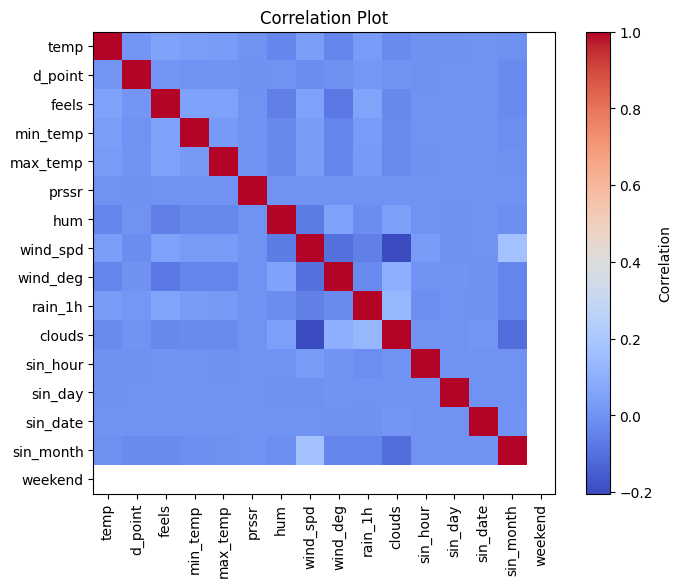

In [ ]:
import matplotlib.pyplot as plt

corr_matrix = train2.corr()

# Create a correlation plot
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation', orientation='vertical')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Plot')
plt.show()

In [ ]:
train2

,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,...,temp_Discretized,d_point_Discretized,feels_Discretized,min_temp_Discretized,max_temp_Discretized,prssr_Discretized,hum_Discretized,wind_spd_Discretized,wind_deg_Discretized,clouds_Discretized
0,24.75,12,23.89,25.76,24.28,25.22,1012.0,4,9,95.0,...,1,1,1,1,1,3,3,1,3,3
1,24.58,12,23.73,25.57,23.99,25.26,1012.0,9,9,95.0,...,1,1,1,1,1,3,3,1,3,3
2,26.60,9,24.06,26.60,26.10,27.39,1012.0,9,4,86.0,...,2,1,1,2,2,3,1,2,3,3
3,27.31,12,24.37,30.90,26.59,28.36,1012.0,9,4,84.0,...,3,1,2,3,3,3,1,1,3,3
4,27.41,12,25.05,31.54,26.58,28.31,1011.0,9,4,87.0,...,3,3,3,3,3,3,1,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341875,25.06,12,24.55,131.53,24.44,25.69,1007.0,4,9,97.0,...,1,2,3,1,1,1,3,1,1,3
341876,24.51,12,24.17,25.58,23.89,25.13,1006.0,4,4,98.0,...,1,1,1,1,1,1,3,1,1,3
341877,24.63,12,24.29,129.32,24.00,126.96,1007.0,9,4,98.0,...,1,1,3,1,3,1,3,3,1,3
341878,26.68,12,24.71,29.76,25.02,27.25,1008.0,4,9,89.0,...,2,2,2,1,2,1,2,2,1,3


In [ ]:
train2.to_csv('checkpoint_train.csv', index = False)
test.to_csv('checkpoint_test.csv', index = False)

## **Feature Extraction**

In [ ]:
from sklearn.model_selection import train_test_split

X = train2.drop(['rain_1h'], axis = 1)
y = train2['rain_1h'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
train_dataset = pd.concat([X_train, y_train], axis = 1)
test_dataset = pd.concat([X_test, y_test], axis = 1)

**Principal Component Analysis**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## **Modeling**

**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

RMSE =  0.880145823903038


**XGBoost**

In [ ]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
bst = xgb.train({'objective': 'reg:squarederror',
                 'booster': 'gbtree',
                 'eval_metric': 'rmse'}, dtrain)
dtest = xgb.DMatrix(X_test, enable_categorical=True)
y_pred = bst.predict(dtest)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

RMSE =  0.7651782488258531


In [ ]:
X_train.columns

Index(['temp', 'd_point', 'feels', 'min_temp', 'max_temp', 'hum', 'wind_spd',
       'wind_deg', 'clouds', 'year', 'month', 'hour', 'sin_hour', 'sin_month'],
      dtype='object')

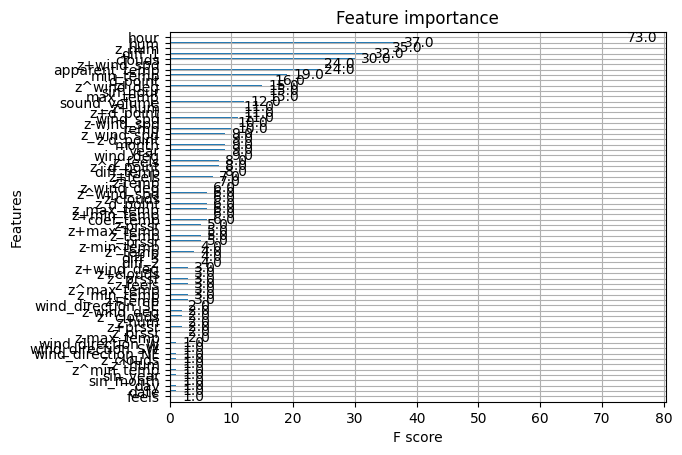

In [ ]:
import matplotlib.pyplot as plt

xgb.plot_importance(bst)
plt.show()

**LightGBM**

In [ ]:
import lightgbm
from lightgbm import LGBMRegressor

model = LGBMRegressor(random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.391529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18655
[LightGBM] [Info] Number of data points in the train set: 273504, number of used features: 92
[LightGBM] [Info] Start training from score 0.361221
RMSE =  0.7560029806611821


**K-Neighbors Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

RMSE =  0.9432315559840195


**Random Forest**

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

RMSE =  0.8718479068073177


**CatBoost**

In [ ]:
import catboost
from catboost import CatBoostRegressor

categorical_features = ['hour','month', 'date', 'day']
model = CatBoostRegressor(cat_features= categorical_features,
                          loss_function='RMSE')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

Learning rate set to 0.099362
0:	learn: 0.9218492	total: 387ms	remaining: 6m 26s
1:	learn: 0.9044873	total: 675ms	remaining: 5m 36s
2:	learn: 0.8898187	total: 1.05s	remaining: 5m 49s
3:	learn: 0.8773394	total: 1.4s	remaining: 5m 47s
4:	learn: 0.8672943	total: 1.78s	remaining: 5m 54s
5:	learn: 0.8582638	total: 2.03s	remaining: 5m 37s
6:	learn: 0.8506646	total: 2.36s	remaining: 5m 35s
7:	learn: 0.8447108	total: 2.71s	remaining: 5m 36s
8:	learn: 0.8390390	total: 3.02s	remaining: 5m 32s
9:	learn: 0.8344299	total: 3.31s	remaining: 5m 27s
10:	learn: 0.8303102	total: 3.59s	remaining: 5m 22s
11:	learn: 0.8259427	total: 3.85s	remaining: 5m 16s
12:	learn: 0.8226597	total: 4.16s	remaining: 5m 15s
13:	learn: 0.8187507	total: 4.45s	remaining: 5m 13s
14:	learn: 0.8160760	total: 4.81s	remaining: 5m 15s
15:	learn: 0.8140885	total: 5.17s	remaining: 5m 18s
16:	learn: 0.8123078	total: 5.54s	remaining: 5m 20s
17:	learn: 0.8099155	total: 5.93s	remaining: 5m 23s
18:	learn: 0.8082200	total: 6.24s	remaining: 

**Voting Regressor**

In [ ]:
from sklearn.ensemble import VotingRegressor

categorical_features = ['hour','month', 'date', 'day']

model1 = LGBMRegressor()
model2 = CatBoostRegressor(cat_features=categorical_features,  # Specify categorical features
                          loss_function='RMSE')

model = VotingRegressor([('lr', model1), ('rf', model2)])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6066
[LightGBM] [Info] Number of data points in the train set: 273504, number of used features: 45
[LightGBM] [Info] Start training from score 0.361221
Learning rate set to 0.099362
0:	learn: 0.9232225	total: 604ms	remaining: 10m 3s
1:	learn: 0.9055009	total: 1.45s	remaining: 12m 5s
2:	learn: 0.8906321	total: 1.91s	remaining: 10m 34s
3:	learn: 0.8783410	total: 2.2s	remaining: 9m 8s
4:	learn: 0.8677290	total: 2.44s	remaining: 8m 4s
5:	learn: 0.8591698	total: 2.73s	remaining: 7m 32s
6:	learn: 0.8513735	total: 3s	remaining: 7m 5s
7:	learn: 0.8444771	total: 3.27s	remaining: 6m 45s
8:	learn: 0.8391605	total: 3.56s	remaining: 6m 32s
9:	learn: 0.8348239	total: 3.84s	remaining: 6m 19s
10:	learn: 0.8300358	total: 4.11s	remaining: 6m 9s
11:	l

**Auto Gluon**

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

model = TabularPredictor(label ='rain_1h').fit(train_data = train_dataset,
                                                        verbosity = 2,
                                                        presets='best_quality',
                                                        time_limit = 1200)
y_pred = model.predict(X_test)
rmse = (mean_squared_error(y_pred, y_test))**(1/2)
print("RMSE = ", rmse)

No path specified. Models will be saved in: "AutogluonModels/ag-20230911_163656/"
Presets specified: ['best_quality']
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=20
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "AutogluonModels/ag-20230911_163656/"
AutoGluon Version:  0.8.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Fri Jun 9 10:57:30 UTC 2023
Disk Space Avail:   81.18 GB / 115.66 GB (70.2%)
Train Data Rows:    240113
Train Data Columns: 26
Label Column: rain_1h
Preprocessing data ...
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (27.1, 0.0, 0.36213, 0.94546)
	If 'regression' is not the correct problem_type, please manually specify the problem_type parameter during predictor init (You may specify problem_type as on

KeyError: ignored

## **Submission**

In [ ]:
train2

,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,...,z6wind_deg,z&wind_deg,wind_direction_N,wind_direction_NE,wind_direction_E,wind_direction_SE,wind_direction_S,wind_direction_SW,wind_direction_W,wind_direction_NW
0,24.75,23.89,25.76,24.28,25.22,1012.0,95.0,0.82,320.0,0.00,...,9.979145,18.0,0,0,0,0,0,0,0,1
1,24.58,23.73,25.57,23.99,25.26,1012.0,95.0,0.96,338.0,0.00,...,9.979145,18.0,0,0,0,0,0,0,0,1
2,26.60,24.06,26.60,26.10,27.39,1012.0,86.0,1.22,339.0,0.00,...,9.979145,1.0,0,0,0,0,0,0,0,1
3,27.31,24.37,30.90,26.59,28.36,1012.0,84.0,1.08,342.0,0.13,...,9.979145,3.0,0,0,0,0,0,0,0,1
4,27.41,25.05,31.54,26.58,28.31,1011.0,87.0,0.86,336.0,0.34,...,2.500000,-6.0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341875,25.06,24.55,40.53,24.44,25.69,1007.0,97.0,0.90,13.0,0.00,...,89.391927,-8.0,1,0,0,0,0,0,0,0
341876,24.51,24.17,25.58,23.89,25.13,1006.0,98.0,0.85,21.0,0.00,...,84.917116,8.0,1,0,0,0,0,0,0,0
341877,24.63,24.29,38.32,24.00,30.96,1007.0,98.0,1.54,26.0,0.00,...,5.377422,5.0,1,0,0,0,0,0,0,0
341878,26.68,24.71,29.76,25.02,27.25,1008.0,89.0,1.46,17.0,0.30,...,5.560276,-9.0,1,0,0,0,0,0,0,0


In [ ]:
test

,datetime_iso,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,...,z6wind_deg,z&wind_deg,wind_direction_N,wind_direction_NE,wind_direction_E,wind_direction_SE,wind_direction_S,wind_direction_SW,wind_direction_W,wind_direction_NW
0,2018-01-01 00:00:00+00:00,26.59,23.66,26.59,26.02,27.16,1009.0,84.0,1.45,355.0,...,NaN,NaN,0,0,0,0,0,0,0,1
1,2018-01-01 01:00:00+00:00,26.51,24.92,26.51,26.06,28.04,1009.0,91.0,1.67,351.0,...,NaN,-4.0,0,0,0,0,0,0,0,1
2,2018-01-01 02:00:00+00:00,28.68,25.71,34.68,28.03,29.30,1009.0,84.0,1.72,345.0,...,NaN,-6.0,0,0,0,0,0,0,0,1
3,2018-01-01 03:00:00+00:00,28.84,25.25,34.51,28.52,29.08,1008.0,81.0,1.49,339.0,...,7.000000,-6.0,0,0,0,0,0,0,0,1
4,2018-01-01 04:00:00+00:00,29.75,24.62,35.38,29.31,30.57,1007.0,74.0,1.39,339.0,...,5.744563,0.0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49363,2023-08-19 19:00:00+00:00,24.37,23.34,25.32,22.70,28.20,1011.0,94.0,1.57,239.0,...,8.500000,0.0,0,0,0,0,0,1,0,0
49364,2023-08-19 20:00:00+00:00,23.87,23.02,24.79,21.91,28.01,1011.0,95.0,1.53,235.0,...,2.000000,-4.0,0,0,0,0,0,1,0,0
49365,2023-08-19 21:00:00+00:00,23.87,23.02,24.79,21.91,28.01,1011.0,95.0,1.53,235.0,...,2.309401,0.0,0,0,0,0,0,1,0,0
49366,2023-08-19 22:00:00+00:00,23.87,23.02,24.79,21.91,28.01,1011.0,95.0,1.53,235.0,...,2.000000,0.0,0,0,0,0,0,1,0,0


In [ ]:
#train2.drop(['datetime_iso'], axis = 1, inplace = True)
#test.drop(['datetime_iso'], axis = 1, inplace = True)

In [ ]:
#test = pd.get_dummies(test, columns = ['wind_direction'])
test.fillna(method = 'bfill', inplace = True)
target = test.drop(['datetime_iso'], axis = 1)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X = pca.fit_transform(X)
target = pca.transform(target)

In [ ]:
from sklearn.ensemble import VotingRegressor
import catboost
from catboost import CatBoostRegressor

categorical_features = ['hour','month', 'date', 'quarter', 'season', 'week']
model = CatBoostRegressor(cat_features=categorical_features,  # Specify categorical features
                          loss_function='RMSE')
model.fit(X, y)
prediction = model.predict(target)

Learning rate set to 0.102928
0:	learn: 0.9189455	total: 643ms	remaining: 10m 42s
1:	learn: 0.8991094	total: 1.27s	remaining: 10m 35s
2:	learn: 0.8823937	total: 1.83s	remaining: 10m 6s
3:	learn: 0.8685427	total: 2.31s	remaining: 9m 35s
4:	learn: 0.8566590	total: 2.77s	remaining: 9m 10s
5:	learn: 0.8480284	total: 3.29s	remaining: 9m 5s
6:	learn: 0.8392166	total: 4.37s	remaining: 10m 19s
7:	learn: 0.8321352	total: 5.37s	remaining: 11m 5s
8:	learn: 0.8254655	total: 6.54s	remaining: 12m
9:	learn: 0.8193813	total: 7.24s	remaining: 11m 56s
10:	learn: 0.8153713	total: 8.96s	remaining: 13m 25s
11:	learn: 0.8112099	total: 10.4s	remaining: 14m 12s
12:	learn: 0.8075598	total: 11.4s	remaining: 14m 22s
13:	learn: 0.8036582	total: 12.2s	remaining: 14m 22s
14:	learn: 0.8007807	total: 13s	remaining: 14m 16s
15:	learn: 0.7982689	total: 13.9s	remaining: 14m 15s
16:	learn: 0.7961693	total: 14.9s	remaining: 14m 20s
17:	learn: 0.7938606	total: 15.8s	remaining: 14m 24s
18:	learn: 0.7922172	total: 16.8s	rema

In [ ]:
submission = pd.DataFrame()
submission['datetime_iso'] = test['datetime_iso']
prediction[prediction < 0] = 0
submission['rain_1h'] = prediction
submission.to_csv('pengumpulan_catboost_part5.csv', index = False)

## **Repositori**

In [ ]:
import hyperopt
from hyperopt import fmin, tpe, hp, Trials
from sklearn.model_selection import cross_val_score, KFold

import numpy as np  # Make sure to import numpy

def hyperopt_lightgbm_kfold(X, y, num_evals=100, num_folds=5):
    """
    Perform hyperparameter tuning for LightGBM using K-Fold cross-validation and Hyperopt.

    Parameters:
    - X: The training feature matrix.
    - y: The training target vector.
    - num_evals: The number of hyperparameter combinations to evaluate (default is 100).
    - num_folds: The number of folds for K-Fold cross-validation (default is 5).

    Returns:
    - A dictionary containing the best hyperparameters found.
    """
    # Define the search space for hyperparameters
    space = {
        'num_leaves': hp.quniform('num_leaves', 10, 100, 1),  # Integer
        'learning_rate': hp.loguniform('learning_rate', np.log(0.001), np.log(0.1)),  # Smaller learning rate
        'max_depth': hp.choice('max_depth', [-1, 5, 10, 15]),  # Limited max_depth
        'min_child_samples': hp.quniform('min_child_samples', 2, 50, 1),  # Integer
        'subsample': hp.uniform('subsample', 0.7, 1.0),  # Increased subsample
        'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),  # Adjusted colsample_bytree
        'reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0),  # Regularization
        'reg_lambda': hp.uniform('reg_lambda', 0.0, 1.0),  # Regularization
        'min_child_weight': hp.loguniform('min_child_weight', np.log(1e-5), np.log(1e5)),  # Increase min_child_weight
        'min_data_in_leaf': hp.quniform('min_data_in_leaf', 1, 100, 1)  # Increase min_data_in_leaf
    }

    # Define the objective function to minimize (e.g., mean squared error)
    def objective(params):
        params['num_leaves'] = int(params['num_leaves'])  # Cast to integer
        params['max_depth'] = int(params['max_depth']) if params['max_depth'] != -1 else -1  # Cast to integer or keep -1
        params['min_child_samples'] = int(params['min_child_samples'])
        params['min_data_in_leaf'] = int(params['min_data_in_leaf'])
        model = LGBMRegressor(**params, verbose=0, force_col_wise=True)  # Use lgb.LGBMRegressor
        model.fit(X_train, y_train)
        rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))  # Fit the model on the entire training set
        print(f'RMSE: {rmse} | Parameters: {params}')
        return rmse

    # Create a Trials object to keep track of optimization results
    trials = Trials()

    # Use TPE (Tree-structured Parzen Estimator) algorithm for optimization
    best = fmin(fn=objective,
                space=space,
                algo=tpe.suggest,
                max_evals=num_evals,
                trials=trials, verbose=0)

    # Return the best hyperparameters found
    return best


In [ ]:
model_lgbm={'colsample_bytree': 0.6476763647316597,
 'learning_rate': 0.07978474875706841,
 'max_depth': 2,
 'min_child_samples': 28,
 'min_child_weight': 7.171132670959499,
 'min_data_in_leaf': 36,
 'num_leaves': 88,
 'reg_alpha': 0.6043673006755673,
 'reg_lambda': 0.6606785101273845,
 'subsample': 0.8479829315528338}

In [ ]:
lgbm_mo=LGBMRegressor(**model_lgbm)
lgbm_mo.fit(X_train,y_train)

[LightGBM] [Warning] min_data_in_leaf is set=36, min_child_samples=28 will be ignored. Current value: min_data_in_leaf=36
[LightGBM] [Warning] min_data_in_leaf is set=36, min_child_samples=28 will be ignored. Current value: min_data_in_leaf=36
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2019
[LightGBM] [Info] Number of data points in the train set: 75597, number of used features: 14
[LightGBM] [Info] Start training from score 0.345558


LGBMRegressor(colsample_bytree=0.6476763647316597,
              learning_rate=0.07978474875706841, max_depth=2,
              min_child_samples=28, min_child_weight=7.171132670959499,
              min_data_in_leaf=36, num_leaves=88, reg_alpha=0.6043673006755673,
              reg_lambda=0.6606785101273845, subsample=0.8479829315528338)

In [ ]:
rmse = (mean_squared_error(y_test, lgbm_mo.predict(X_test)))**(1/2)
print("RMSE = ", rmse)

[LightGBM] [Warning] min_data_in_leaf is set=36, min_child_samples=28 will be ignored. Current value: min_data_in_leaf=36
RMSE =  0.801700621406738


In [ ]:
model_lgbm=hyperopt_lightgbm_kfold(X_train, y_train, num_evals=100, num_folds=10)

In [ ]:
submission= pd.read_csv('sample_submission.csv')
submission['rain_1h']= lgbm_mo.predict(test)

[LightGBM] [Warning] min_data_in_leaf is set=61, min_child_samples=23 will be ignored. Current value: min_data_in_leaf=61


In [ ]:
model_lgbm

{'colsample_bytree': 0.6476763647316597,
 'learning_rate': 0.07978474875706841,
 'max_depth': 2,
 'min_child_samples': 28.0,
 'min_child_weight': 7.171132670959499,
 'min_data_in_leaf': 36.0,
 'num_leaves': 88.0,
 'reg_alpha': 0.6043673006755673,
 'reg_lambda': 0.6606785101273845,
 'subsample': 0.8479829315528338}

In [ ]:
temp_limit=34.4
feels_limit=41.20
mind_temp_limit=33.0
mind_temp_limit_bawah=20
max_temp_bawah=23.22
max_temp_atas=35.68
wind_spd_atas=4.88
wind_deg=360
prssr_atas=1016
prsr_bawah=1002
hum_bawah=47
hum_atas=100

In [ ]:
train3 = train2[(train2['temp']<=temp_limit) & (train2['feels']<=feels_limit) & (train2['min_temp']>=mind_temp_limit_bawah) & (train2['min_temp']<=mind_temp_limit) & (train2['max_temp']>=max_temp_bawah) & (train2['max_temp']<=max_temp_atas) & (train2['wind_spd']<=wind_spd_atas) & (train2['wind_deg']<=wind_deg) & (train2['prssr']<=prssr_atas) & (train2['prssr']>=prsr_bawah) & (train2['hum']>=hum_bawah) & (train2['hum']<=hum_atas) & (train2.d_point<50)]